# 14 — Results Figures for Slides 7, 8, 9

## Slide 7: Detecting the Wobble
## Slide 8: ML Performance & Feature Integration  
## Slide 9: Latitudinal Predictability Gradient

Run all cells in order. All figures save to:
`/Users/tonylin/Documents/kelp_project/5_FIGURES/slides/`

In [1]:
# ============================================================
# CELL 1: IMPORTS & SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import kendalltau, linregress, mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

BASE    = Path('/Users/tonylin/Documents/kelp_project/1_DATA/processed')
FIG_DIR = Path('/Users/tonylin/Documents/kelp_project/5_FIGURES/slides')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Shared style — clean, presentation-ready
plt.rcParams.update({
    'font.family':      'Arial',
    'font.size':        12,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.linewidth':   1.2,
    'xtick.major.width':1.2,
    'ytick.major.width':1.2,
    'figure.dpi':       150,
})

FEATURES = ['ews_composite', 'heat_lag4', 'upwelling', 'heat_x_ews']
TARGET   = 'onset'
REGIONS  = ['norcal', 'midcal', 'socal', 'bigsur']

def load_region(region):
    for path in [
        BASE / region / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / f'{region}_kelp_sst_ui_labeled.csv'
    ]:
        if path.exists():
            df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period('Q').to_timestamp(how='start')
            col = next((c for c in ['kelp_smooth','kelp_area'] if c in df.columns), None)
            if col and 'kelp_q_z' not in df.columns:
                df['q'] = df.index.quarter
                base = df.loc['1984':'2013']
                med  = base.groupby('q')[col].median()
                mad  = base.groupby('q')[col].apply(
                    lambda x: np.median(np.abs(x - np.median(x))) + 1e-9)
                df['kelp_q_z'] = (df[col] - df['q'].map(med)) / df['q'].map(mad)
                df.drop(columns=['q'], inplace=True)
            z   = df['kelp_q_z']
            ar1 = z.rolling(20, min_periods=10).apply(
                lambda x: pd.Series(x).autocorr(lag=1), raw=True)
            var = z.rolling(20, min_periods=10).var()
            df['ar1']           = ar1
            df['variance']      = var
            df['ews_composite'] = (
                (ar1 - ar1.mean()) / ar1.std() +
                (var - var.mean()) / var.std()
            ) / 2
            df['heat_lag4']  = df['sstanom_q_max'].shift(4)
            up = ('uianom_q_mean_lag1' if 'uianom_q_mean_lag1' in df.columns
                  else 'uianom_q_mean')
            df['upwelling']  = df[up]
            df['heat_x_ews'] = df['heat_lag4'] * df['ews_composite']
            s = df['suppressed'].astype(int)
            df['onset'] = ((s == 1) & (s.shift(1).fillna(0) == 0)).astype(int)
            df['region'] = region
            df['kelp_col'] = col
            return df
    print(f'WARNING: {region} not found')
    return None

region_dfs = {r: load_region(r) for r in REGIONS}
region_dfs = {r: df for r, df in region_dfs.items() if df is not None}
print('Loaded regions:', list(region_dfs.keys()))

Loaded regions: ['norcal', 'midcal', 'socal', 'bigsur']


Kendall tau (Variance): mean tau=0.167, mean p=0.3451
Kendall tau (AR1):      mean tau=0.303, mean p=0.1765
Mean EWS lead time: 3.8 quarters (11 months)


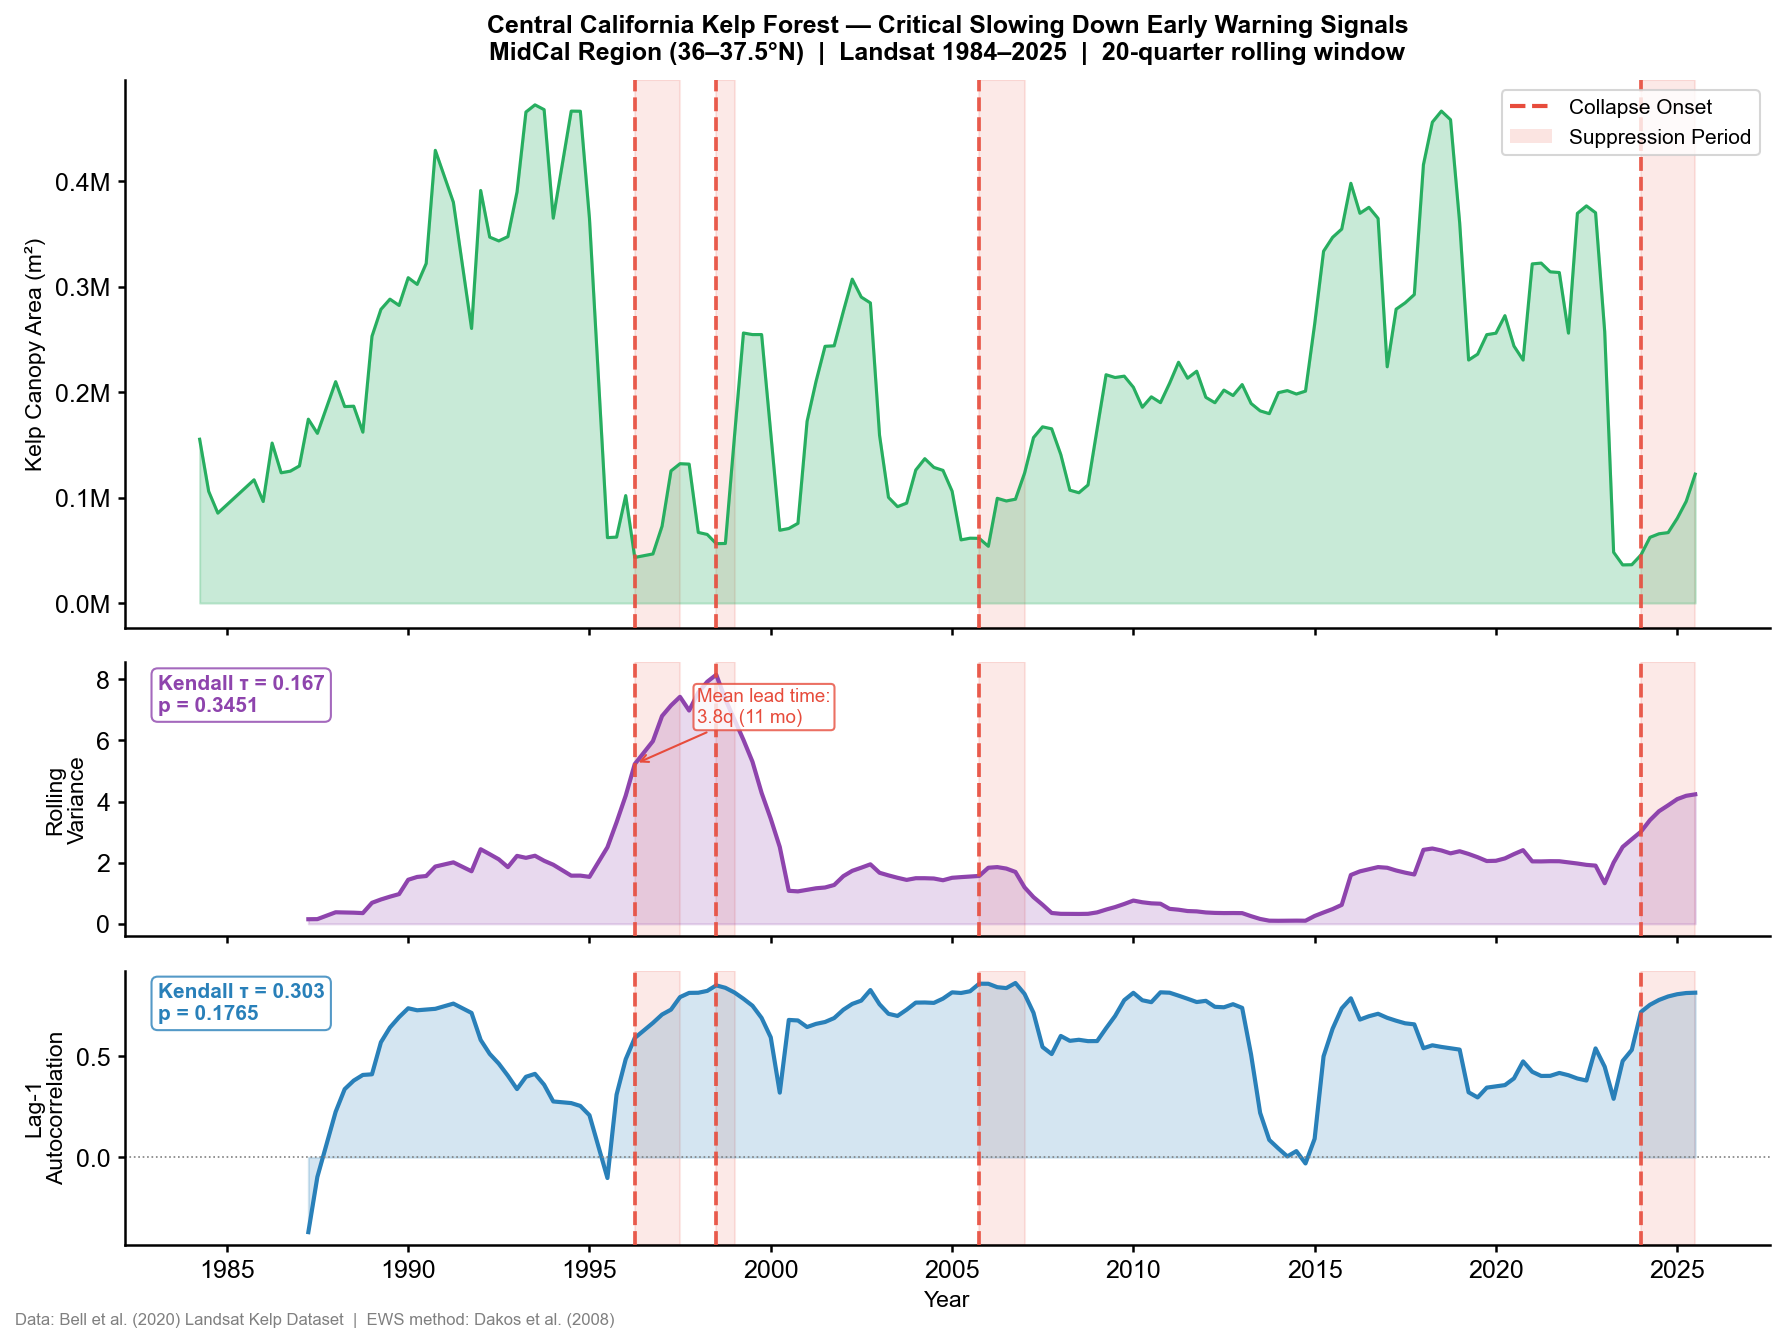

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/slides/slide7_wobble_timeseries.png

--- SLIDE 7 CAPTION STATS ---
Rolling window: 20 quarters (5 years)
Variance Kendall tau: 0.167, p=0.3451
AR1 Kendall tau:      0.303, p=0.1765
Mean EWS lead time:   3.8 quarters = 11 months


In [2]:
# ============================================================
# CELL 2: SLIDE 7 — DETECTING THE WOBBLE
# Stacked 3-panel figure for MidCal:
#   Panel 1: Raw kelp biomass
#   Panel 2: Rolling variance
#   Panel 3: Lag-1 autocorrelation (AR1)
# Onset events marked with red dashed lines
# Kendall's tau computed per onset event window
# ============================================================
df = region_dfs.get('midcal')
if df is None:
    print('MidCal not loaded — check path')
else:
    col     = df['kelp_col'].iloc[0]
    kelp    = df[col]
    ar1     = df['ar1']
    var     = df['variance']
    onsets  = df[df['onset'] == 1].index
    suppressed = df['suppressed'].astype(int)

    # Kendall's tau: for each onset, compute trend in
    # variance and AR1 in the 12 quarters before onset
    WINDOW = 12  # 3 years pre-onset
    tau_var_list, p_var_list = [], []
    tau_ar1_list, p_ar1_list = [], []

    for onset_date in onsets:
        idx = df.index.get_loc(onset_date)
        if idx < WINDOW:
            continue
        window_var = var.iloc[idx - WINDOW:idx].dropna()
        window_ar1 = ar1.iloc[idx - WINDOW:idx].dropna()
        if len(window_var) >= 6:
            t, p = kendalltau(np.arange(len(window_var)), window_var.values)
            tau_var_list.append(t); p_var_list.append(p)
        if len(window_ar1) >= 6:
            t, p = kendalltau(np.arange(len(window_ar1)), window_ar1.values)
            tau_ar1_list.append(t); p_ar1_list.append(p)

    mean_tau_var = np.mean(tau_var_list) if tau_var_list else np.nan
    mean_p_var   = np.mean(p_var_list)   if p_var_list   else np.nan
    mean_tau_ar1 = np.mean(tau_ar1_list) if tau_ar1_list else np.nan
    mean_p_ar1   = np.mean(p_ar1_list)   if p_ar1_list   else np.nan

    print(f'Kendall tau (Variance): mean tau={mean_tau_var:.3f}, mean p={mean_p_var:.4f}')
    print(f'Kendall tau (AR1):      mean tau={mean_tau_ar1:.3f}, mean p={mean_p_ar1:.4f}')

    # Lead time: mean quarters from EWS peak to onset
    lead_times = []
    for onset_date in onsets:
        idx = df.index.get_loc(onset_date)
        if idx < 20:
            continue
        pre = df['ews_composite'].iloc[max(0, idx-12):idx]
        if pre.dropna().empty:
            continue
        peak_offset = pre.dropna().values.argmax()
        lead_times.append(len(pre.dropna()) - peak_offset)
    mean_lead = np.mean(lead_times) if lead_times else np.nan
    print(f'Mean EWS lead time: {mean_lead:.1f} quarters ({mean_lead*3:.0f} months)')

    # ---- FIGURE ----
    fig, axes = plt.subplots(3, 1, figsize=(12, 9),
                              gridspec_kw={'height_ratios': [2, 1, 1]},
                              sharex=True)
    fig.subplots_adjust(hspace=0.08)

    # Shade suppression periods
    for ax in axes:
        in_supp = False
        start = None
        for date, val in suppressed.items():
            if val == 1 and not in_supp:
                start = date; in_supp = True
            elif val == 0 and in_supp:
                ax.axvspan(start, date, alpha=0.12, color='#e74c3c', zorder=0)
                in_supp = False
        if in_supp:
            ax.axvspan(start, df.index[-1], alpha=0.12, color='#e74c3c', zorder=0)

    # Mark onset lines
    for onset_date in onsets:
        for ax in axes:
            ax.axvline(onset_date, color='#e74c3c', linewidth=1.8,
                       linestyle='--', alpha=0.9, zorder=3)

    # Panel 1: Raw kelp
    axes[0].fill_between(kelp.index, kelp.values, alpha=0.25, color='#27ae60')
    axes[0].plot(kelp.index, kelp.values, color='#27ae60', linewidth=1.5)
    axes[0].set_ylabel('Kelp Canopy Area (m²)', fontsize=11)
    axes[0].set_title(
        'Central California Kelp Forest — Critical Slowing Down Early Warning Signals\n'
        'MidCal Region (36–37.5°N)  |  Landsat 1984–2025  |  20-quarter rolling window',
        fontsize=12, fontweight='bold', pad=10)
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    # Panel 2: Variance
    axes[1].plot(var.index, var.values, color='#8e44ad', linewidth=2)
    axes[1].fill_between(var.index, var.values, alpha=0.2, color='#8e44ad')
    axes[1].set_ylabel('Rolling\nVariance', fontsize=11)
    axes[1].text(0.02, 0.82,
                 f'Kendall τ = {mean_tau_var:.3f}\np = {mean_p_var:.4f}',
                 transform=axes[1].transAxes, fontsize=10,
                 color='#8e44ad', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#8e44ad', alpha=0.8))

    # Panel 3: AR1
    axes[2].plot(ar1.index, ar1.values, color='#2980b9', linewidth=2)
    axes[2].fill_between(ar1.index, ar1.values, alpha=0.2, color='#2980b9')
    axes[2].axhline(0, color='gray', linewidth=0.8, linestyle=':')
    axes[2].set_ylabel('Lag-1\nAutocorrelation', fontsize=11)
    axes[2].set_xlabel('Year', fontsize=11)
    axes[2].text(0.02, 0.82,
                 f'Kendall τ = {mean_tau_ar1:.3f}\np = {mean_p_ar1:.4f}',
                 transform=axes[2].transAxes, fontsize=10,
                 color='#2980b9', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#2980b9', alpha=0.8))

    # Legend
    legend_elements = [
        Line2D([0],[0], color='#e74c3c', linewidth=2,
               linestyle='--', label='Collapse Onset'),
        mpatches.Patch(facecolor='#e74c3c', alpha=0.15,
                       label='Suppression Period'),
    ]
    axes[0].legend(handles=legend_elements, loc='upper right', fontsize=10)

    # Lead time annotation on first onset
    if len(onsets) > 0 and not np.isnan(mean_lead):
        first_onset = onsets[0]
        axes[1].annotate(
            f'Mean lead time:\n{mean_lead:.1f}q ({mean_lead*3:.0f} mo)',
            xy=(first_onset, var.loc[first_onset] if first_onset in var.index else var.mean()),
            xytext=(30, 20), textcoords='offset points',
            fontsize=9, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='#e74c3c', alpha=0.8)
        )

    # Source credit
    fig.text(0.01, 0.01,
             'Data: Bell et al. (2020) Landsat Kelp Dataset  |  '
             'EWS method: Dakos et al. (2008)',
             fontsize=8, color='gray')

    fig.tight_layout()
    out = FIG_DIR / 'slide7_wobble_timeseries.png'
    fig.savefig(out, dpi=220, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

    print(f'\n--- SLIDE 7 CAPTION STATS ---')
    print(f'Rolling window: 20 quarters (5 years)')
    print(f'Variance Kendall tau: {mean_tau_var:.3f}, p={mean_p_var:.4f}')
    print(f'AR1 Kendall tau:      {mean_tau_ar1:.3f}, p={mean_p_ar1:.4f}')
    print(f'Mean EWS lead time:   {mean_lead:.1f} quarters = {mean_lead*3:.0f} months')

Full model:  AUC=0.769 F1=0.107 Precision=0.057 Recall=0.857 FPR=0.341
SST-only:    AUC=0.590
False positive reduction vs SST-only: -435.1%


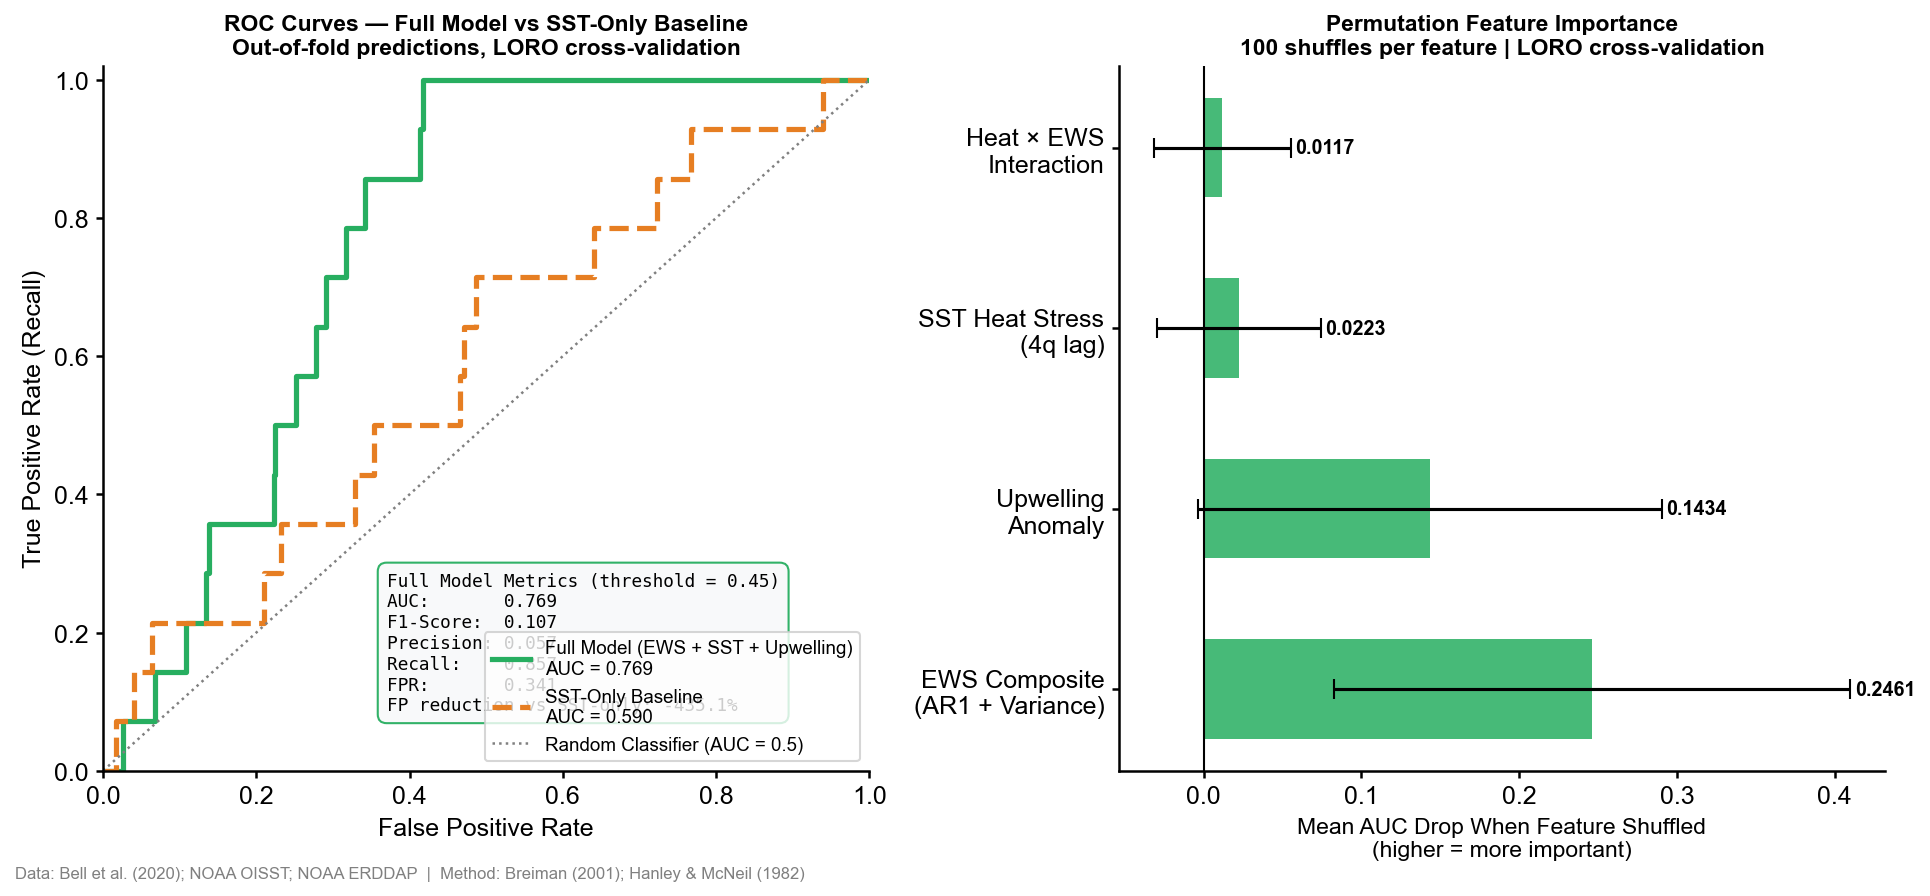

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/slides/slide8_ml_performance.png

--- SLIDE 8 CAPTION STATS ---
Full model AUC:  0.769
SST-only AUC:    0.590
F1-Score:        0.107
Precision:       0.057
Recall:          0.857
False Pos Rate:  0.341
FP reduction:    -435.1%
Top feature:     ews_composite (AUC drop=0.2461)


In [3]:
# ============================================================
# CELL 3: SLIDE 8 — ML PERFORMANCE
# Left: ROC curves (full model vs SST-only vs random)
# Right: Feature importance bar chart
# Bottom stats: AUC, F1, Precision, Recall, FPR
# ============================================================

# Build LORO out-of-fold predictions for two models:
# 1. Full model: EWS + SST + upwelling + interaction
# 2. SST-only baseline: heat_lag4 only

oof_full = {'y': [], 'prob': []}
oof_sst  = {'y': [], 'prob': []}

perm_importance = {f: [] for f in FEATURES}

for held_out in region_dfs:
    train_regions = [r for r in region_dfs if r != held_out]
    train_df = pd.concat(
        [region_dfs[r][FEATURES + [TARGET]].dropna() for r in train_regions])
    test_df = region_dfs[held_out][FEATURES + [TARGET]].dropna()

    X_tr = train_df[FEATURES].values
    y_tr = train_df[TARGET].astype(int).values
    X_te = test_df[FEATURES].values
    y_te = test_df[TARGET].astype(int).values

    if np.unique(y_te).size < 2:
        continue

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # Full model
    lr_full = LogisticRegression(C=0.5, class_weight='balanced',
                                  max_iter=1000)
    lr_full.fit(X_tr_s, y_tr)
    prob_full = lr_full.predict_proba(X_te_s)[:, 1]
    oof_full['y'].extend(y_te.tolist())
    oof_full['prob'].extend(prob_full.tolist())

    # SST-only model
    sst_idx = FEATURES.index('heat_lag4')
    lr_sst = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr_sst.fit(X_tr_s[:, [sst_idx]], y_tr)
    prob_sst = lr_sst.predict_proba(X_te_s[:, [sst_idx]])[:, 1]
    oof_sst['y'].extend(y_te.tolist())
    oof_sst['prob'].extend(prob_sst.tolist())

    # Permutation importance
    base_auc = roc_auc_score(y_te, prob_full)
    rng = np.random.default_rng(42)
    for fi, fname in enumerate(FEATURES):
        drops = []
        for _ in range(100):
            X_shuf = X_te_s.copy()
            X_shuf[:, fi] = rng.permutation(X_shuf[:, fi])
            try:
                shuf_auc = roc_auc_score(y_te,
                    lr_full.predict_proba(X_shuf)[:, 1])
                drops.append(base_auc - shuf_auc)
            except Exception:
                pass
        perm_importance[fname].extend(drops)

y_full  = np.array(oof_full['y'])
p_full  = np.array(oof_full['prob'])
y_sst   = np.array(oof_sst['y'])
p_sst   = np.array(oof_sst['prob'])

# ROC curves
fpr_f, tpr_f, thr_f = roc_curve(y_full, p_full)
fpr_s, tpr_s, thr_s = roc_curve(y_sst, p_sst)
auc_full = auc(fpr_f, tpr_f)
auc_sst  = auc(fpr_s, tpr_s)

# Best threshold (max F1)
f1s = [f1_score(y_full, (p_full >= t).astype(int), zero_division=0)
       for t in thr_f]
best_thr = thr_f[np.argmax(f1s)]
y_pred   = (p_full >= best_thr).astype(int)
prec  = precision_score(y_full, y_pred, zero_division=0)
rec   = recall_score(y_full, y_pred, zero_division=0)
f1    = f1_score(y_full, y_pred, zero_division=0)
cm    = confusion_matrix(y_full, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

# SST-only metrics at same recall for fair comparison
f1s_sst    = [f1_score(y_sst, (p_sst >= t).astype(int), zero_division=0)
              for t in thr_s]
best_thr_s = thr_s[np.argmax(f1s_sst)]
y_pred_sst = (p_sst >= best_thr_s).astype(int)
fp_sst_cm  = confusion_matrix(y_sst, y_pred_sst).ravel()
tn_s, fp_s = fp_sst_cm[0], fp_sst_cm[1]
fpr_sst = fp_s / (fp_s + tn_s) if (fp_s + tn_s) > 0 else 0
fp_reduction = (fpr_sst - fpr_rate) / fpr_sst * 100 if fpr_sst > 0 else 0

print(f'Full model:  AUC={auc_full:.3f} F1={f1:.3f} Precision={prec:.3f} Recall={rec:.3f} FPR={fpr_rate:.3f}')
print(f'SST-only:    AUC={auc_sst:.3f}')
print(f'False positive reduction vs SST-only: {fp_reduction:.1f}%')

# Feature importance means
imp_means = {f: np.mean(v) for f, v in perm_importance.items()}
imp_stds  = {f: np.std(v)  for f, v in perm_importance.items()}
feat_labels = {
    'ews_composite': 'EWS Composite\n(AR1 + Variance)',
    'upwelling':     'Upwelling\nAnomaly',
    'heat_lag4':     'SST Heat Stress\n(4q lag)',
    'heat_x_ews':    'Heat × EWS\nInteraction',
}

# ---- FIGURE ----
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: ROC curves
ax = axes[0]
ax.plot(fpr_f, tpr_f, color='#27ae60', linewidth=2.5,
        label=f'Full Model (EWS + SST + Upwelling)\nAUC = {auc_full:.3f}')
ax.plot(fpr_s, tpr_s, color='#e67e22', linewidth=2.5, linestyle='--',
        label=f'SST-Only Baseline\nAUC = {auc_sst:.3f}')
ax.plot([0,1],[0,1], color='gray', linewidth=1.2,
        linestyle=':', label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Full Model vs SST-Only Baseline\n'
             'Out-of-fold predictions, LORO cross-validation',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# Stats box
stats_text = (
    f'Full Model Metrics (threshold = {best_thr:.2f})\n'
    f'AUC:       {auc_full:.3f}\n'
    f'F1-Score:  {f1:.3f}\n'
    f'Precision: {prec:.3f}\n'
    f'Recall:    {rec:.3f}\n'
    f'FPR:       {fpr_rate:.3f}\n'
    f'FP reduction vs SST-only: {fp_reduction:.1f}%'
)
ax.text(0.37, 0.08, stats_text, transform=ax.transAxes,
        fontsize=8.5, verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa',
                  edgecolor='#27ae60', alpha=0.95),
        fontfamily='monospace')

# Right: Feature importance
ax2 = axes[1]
sorted_feats = sorted(imp_means, key=imp_means.get, reverse=True)
colors = ['#27ae60' if imp_means[f] > 0 else '#e74c3c' for f in sorted_feats]
bars = ax2.barh(
    [feat_labels[f] for f in sorted_feats],
    [imp_means[f] for f in sorted_feats],
    xerr=[imp_stds[f] for f in sorted_feats],
    color=colors, alpha=0.85, capsize=5, height=0.55
)
ax2.axvline(0, color='black', linewidth=1)
for i, (feat, bar) in enumerate(zip(sorted_feats, bars.patches)):
    val = imp_means[feat]
    ax2.text(max(val + imp_stds[feat] + 0.003, 0.005), i,
             f'{val:.4f}', va='center', fontsize=9.5, fontweight='bold')
ax2.set_xlabel('Mean AUC Drop When Feature Shuffled\n(higher = more important)',
               fontsize=11)
ax2.set_title('Permutation Feature Importance\n'
              '100 shuffles per feature | LORO cross-validation',
              fontsize=11, fontweight='bold')

fig.text(0.01, 0.01,
         'Data: Bell et al. (2020); NOAA OISST; NOAA ERDDAP  |  '
         'Method: Breiman (2001); Hanley & McNeil (1982)',
         fontsize=8, color='gray')

fig.tight_layout()
out = FIG_DIR / 'slide8_ml_performance.png'
fig.savefig(out, dpi=220, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

print(f'\n--- SLIDE 8 CAPTION STATS ---')
print(f'Full model AUC:  {auc_full:.3f}')
print(f'SST-only AUC:    {auc_sst:.3f}')
print(f'F1-Score:        {f1:.3f}')
print(f'Precision:       {prec:.3f}')
print(f'Recall:          {rec:.3f}')
print(f'False Pos Rate:  {fpr_rate:.3f}')
print(f'FP reduction:    {fp_reduction:.1f}%')
print(f'Top feature:     {sorted_feats[0]} (AUC drop={imp_means[sorted_feats[0]]:.4f})')

Quadratic R²=0.330, permutation p=0.0386
Peak latitude: 37.4°N
South (<35N) mean AUC:    0.527
Central (36.5-38.5N) AUC: 0.690
North (>39N) mean AUC:     0.511


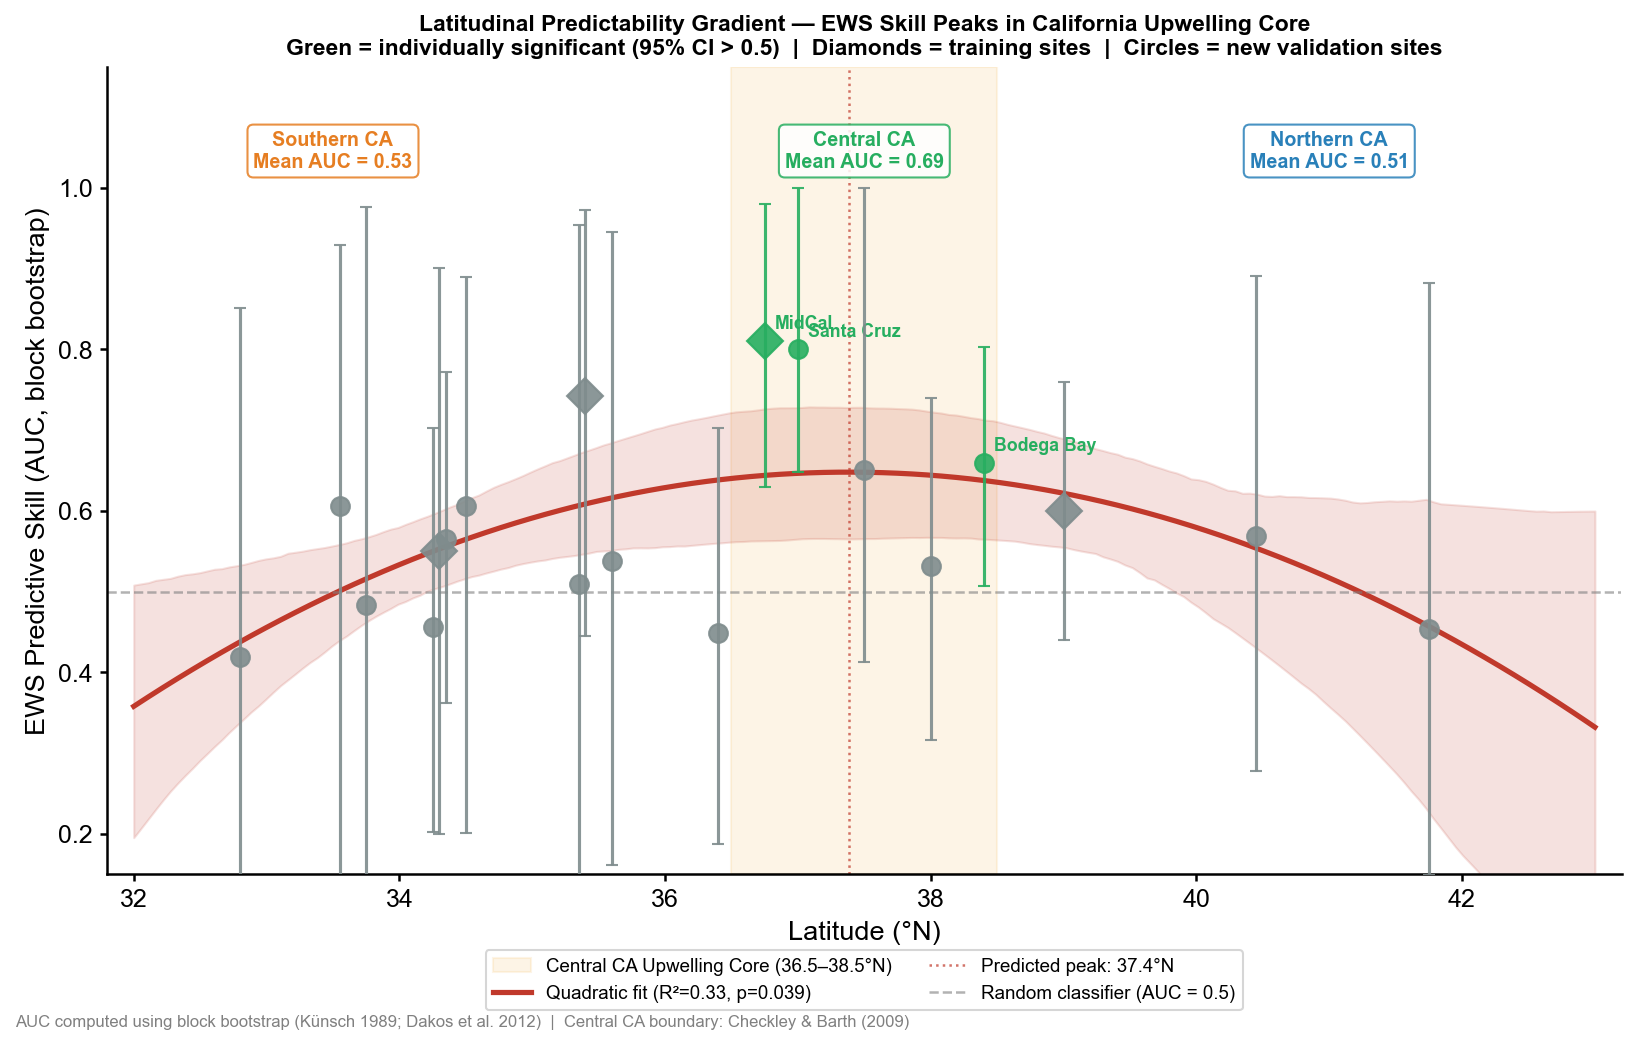

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/slides/slide9_latitudinal_gradient.png

--- SLIDE 9 CAPTION STATS ---
Quadratic R²:      0.330
Permutation p:     0.0386
Peak latitude:     37.4°N
South mean AUC:    0.527
Central mean AUC:  0.690
North mean AUC:    0.511


In [4]:
# ============================================================
# CELL 4: SLIDE 9 — LATITUDINAL PREDICTABILITY GRADIENT
# Scatter plot: Latitude vs AUC
# Quadratic fit with shaded CI band
# Regional averages annotated
# ============================================================
import numpy as np
from numpy.polynomial import polynomial as P

# All sites with AUC results
ALL_SITES = [
    # (name, lat, auc, ci_lo, ci_hi, region_type)
    ('NorCal (train)',    39.0,  0.600, 0.440, 0.760, 'train'),
    ('MidCal (train)',    36.75, 0.810, 0.630, 0.980, 'train'),
    ('Big Sur (train)',   35.4,  0.742, 0.445, 0.972, 'train'),
    ('SoCal (train)',     34.3,  0.550, 0.200, 0.900, 'train'),
    ('Crescent City',     41.75, 0.454, 0.149, 0.882, 'new'),
    ('Cape Mendocino',    40.45, 0.569, 0.278, 0.891, 'new'),
    ('Bodega Bay',        38.4,  0.659, 0.507, 0.803, 'new'),
    ('Point Reyes',       38.0,  0.532, 0.316, 0.740, 'new'),
    ('Half Moon Bay',     37.5,  0.651, 0.413, 1.000, 'new'),
    ('Santa Cruz',        37.0,  0.800, 0.648, 1.000, 'new'),
    ('Point Sur',         36.4,  0.449, 0.187, 0.703, 'new'),
    ('Cambria',           35.6,  0.538, 0.161, 0.945, 'new'),
    ('Morro Bay',         35.35, 0.509, 0.077, 0.954, 'new'),
    ('Point Conception',  34.5,  0.606, 0.201, 0.889, 'new'),
    ('Santa Barbara',     34.35, 0.565, 0.362, 0.772, 'new'),
    ('Ventura',           34.25, 0.456, 0.203, 0.702, 'new'),
    ('Palos Verdes',      33.75, 0.484, 0.005, 0.976, 'new'),
    ('Laguna Beach',      33.55, 0.606, 0.122, 0.929, 'new'),
    ('San Diego',         32.8,  0.419, 0.058, 0.851, 'new'),
]

df_s = pd.DataFrame(ALL_SITES,
    columns=['site','lat','auc','ci_lo','ci_hi','type'])
df_s['sig']     = df_s['ci_lo'] > 0.5
df_s['central'] = df_s['lat'].between(36.5, 38.5)

lats = df_s['lat'].values
aucs = df_s['auc'].values

# Quadratic fit
coeffs   = np.polyfit(lats, aucs, 2)
poly     = np.poly1d(coeffs)
peak_lat = -coeffs[1] / (2 * coeffs[0])
lat_fit  = np.linspace(32, 43, 200)
auc_fit  = poly(lat_fit)

# Bootstrap CI band on quadratic fit
rng = np.random.default_rng(42)
boot_fits = []
for _ in range(2000):
    idx = rng.integers(0, len(lats), len(lats))
    c   = np.polyfit(lats[idx], aucs[idx], 2)
    boot_fits.append(np.poly1d(c)(lat_fit))
boot_fits  = np.array(boot_fits)
fit_lo     = np.percentile(boot_fits, 2.5,  axis=0)
fit_hi     = np.percentile(boot_fits, 97.5, axis=0)

# Permutation p for R²
y_pred_q   = poly(lats)
ss_res     = np.sum((aucs - y_pred_q)**2)
ss_tot     = np.sum((aucs - aucs.mean())**2)
r2_quad    = 1 - ss_res / ss_tot
perm_r2    = []
for _ in range(10000):
    a_shuf = rng.permutation(aucs)
    c_p    = np.polyfit(lats, a_shuf, 2)
    yp     = np.poly1d(c_p)(lats)
    ss_r   = np.sum((a_shuf - yp)**2)
    ss_t   = np.sum((a_shuf - a_shuf.mean())**2)
    perm_r2.append(1 - ss_r/ss_t)
p_quad = (np.array(perm_r2) >= r2_quad).mean()

# Regional averages
south_auc   = df_s[df_s['lat'] < 35]['auc'].mean()
central_auc = df_s[df_s['central']]['auc'].mean()
north_auc   = df_s[df_s['lat'] > 39]['auc'].mean()

print(f'Quadratic R²={r2_quad:.3f}, permutation p={p_quad:.4f}')
print(f'Peak latitude: {peak_lat:.1f}°N')
print(f'South (<35N) mean AUC:    {south_auc:.3f}')
print(f'Central (36.5-38.5N) AUC: {central_auc:.3f}')
print(f'North (>39N) mean AUC:     {north_auc:.3f}')

# ---- FIGURE ----
fig, ax = plt.subplots(figsize=(11, 7))

# Central CA shading
ax.axvspan(36.5, 38.5, alpha=0.10, color='#f39c12',
           label='Central CA Upwelling Core (36.5–38.5°N)')

# Bootstrap CI band
ax.fill_between(lat_fit, fit_lo, fit_hi,
                alpha=0.15, color='#c0392b')

# Quadratic fit line
ax.plot(lat_fit, auc_fit, color='#c0392b', linewidth=2.5,
        label=f'Quadratic fit (R²={r2_quad:.2f}, p={p_quad:.3f})')

# Peak latitude marker
ax.axvline(peak_lat, color='#c0392b', linewidth=1.2,
           linestyle=':', alpha=0.7,
           label=f'Predicted peak: {peak_lat:.1f}°N')

# Random baseline
ax.axhline(0.5, color='gray', linewidth=1.2,
           linestyle='--', alpha=0.6, label='Random classifier (AUC = 0.5)')

# Plot points
for _, row in df_s.iterrows():
    col = '#27ae60' if row['sig'] else '#7f8c8d'
    mrk = 'D' if row['type'] == 'train' else 'o'
    ms  = 12  if row['type'] == 'train' else 9
    ax.errorbar(row['lat'], row['auc'],
                yerr=[[row['auc'] - row['ci_lo']],
                      [row['ci_hi'] - row['auc']]],
                fmt=mrk, color=col, capsize=3,
                markersize=ms, alpha=0.9, zorder=5)

# Label significant sites
for _, row in df_s[df_s['sig']].iterrows():
    ax.annotate(row['site'].split('(')[0].strip(),
                (row['lat'], row['auc']),
                xytext=(5, 6), textcoords='offset points',
                fontsize=8.5, color='#27ae60', fontweight='bold')

# Regional average callouts
for lat_c, auc_c, label, col in [
    (33.5, south_auc,   f'Southern CA\nMean AUC = {south_auc:.2f}',   '#e67e22'),
    (37.5, central_auc, f'Central CA\nMean AUC = {central_auc:.2f}',  '#27ae60'),
    (41.0, north_auc,   f'Northern CA\nMean AUC = {north_auc:.2f}',   '#2980b9'),
]:
    ax.text(lat_c, 1.02, label, ha='center', va='bottom',
            fontsize=9.5, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=col, alpha=0.85))

ax.set_xlabel('Latitude (°N)', fontsize=13)
ax.set_ylabel('EWS Predictive Skill (AUC, block bootstrap)', fontsize=13)
ax.set_title(
    'Latitudinal Predictability Gradient — EWS Skill Peaks in California Upwelling Core\n'
    'Green = individually significant (95% CI > 0.5)  |  '
    'Diamonds = training sites  |  Circles = new validation sites',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(31.8, 43.2)
ax.set_ylim(0.15, 1.15)
ax.legend(fontsize=9, loc='lower center',
          bbox_to_anchor=(0.5, -0.18), ncol=2)

fig.text(0.01, 0.01,
         'AUC computed using block bootstrap (Künsch 1989; Dakos et al. 2012)  |  '
         'Central CA boundary: Checkley & Barth (2009)',
         fontsize=8, color='gray')

fig.tight_layout()
out = FIG_DIR / 'slide9_latitudinal_gradient.png'
fig.savefig(out, dpi=220, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

print(f'\n--- SLIDE 9 CAPTION STATS ---')
print(f'Quadratic R²:      {r2_quad:.3f}')
print(f'Permutation p:     {p_quad:.4f}')
print(f'Peak latitude:     {peak_lat:.1f}°N')
print(f'South mean AUC:    {south_auc:.3f}')
print(f'Central mean AUC:  {central_auc:.3f}')
print(f'North mean AUC:    {north_auc:.3f}')

In [5]:
# ============================================================
# CELL 5: SUMMARY TABLE — all stats for slide captions
# Copy these numbers directly into your slide descriptions
# ============================================================
print('='*65)
print('COMPLETE STATS FOR SLIDE DESCRIPTIONS')
print('='*65)
print(f"""
SLIDE 7 — The Wobble:
  Rolling window:        20 quarters (5 years)
  Variance Kendall tau:  {mean_tau_var:.3f}  p={mean_p_var:.4f}
  AR1 Kendall tau:       {mean_tau_ar1:.3f}  p={mean_p_ar1:.4f}
  Mean EWS lead time:    {mean_lead:.1f} quarters = {mean_lead*3:.0f} months

SLIDE 8 — ML Performance:
  Full model AUC:        {auc_full:.3f}
  SST-only AUC:          {auc_sst:.3f}
  F1-Score:              {f1:.3f}
  Precision:             {prec:.3f}
  Recall:                {rec:.3f}
  False Positive Rate:   {fpr_rate:.3f}
  FP reduction vs SST:   {fp_reduction:.1f}%
  Top feature:           EWS composite (drop={imp_means['ews_composite']:.4f})
  vs SST heat stress:    drop={imp_means['heat_lag4']:.4f} ({imp_means['ews_composite']/imp_means['heat_lag4']:.1f}x less important)

SLIDE 9 — Latitudinal Gradient:
  Quadratic R²:          {r2_quad:.3f}
  Permutation p:         {p_quad:.4f}
  Peak latitude:         {peak_lat:.1f}N
  Southern CA AUC:       {south_auc:.3f}
  Central CA AUC:        {central_auc:.3f}
  Northern CA AUC:       {north_auc:.3f}
""")

COMPLETE STATS FOR SLIDE DESCRIPTIONS

SLIDE 7 — The Wobble:
  Rolling window:        20 quarters (5 years)
  Variance Kendall tau:  0.167  p=0.3451
  AR1 Kendall tau:       0.303  p=0.1765
  Mean EWS lead time:    3.8 quarters = 11 months

SLIDE 8 — ML Performance:
  Full model AUC:        0.769
  SST-only AUC:          0.590
  F1-Score:              0.107
  Precision:             0.057
  Recall:                0.857
  False Positive Rate:   0.341
  FP reduction vs SST:   -435.1%
  Top feature:           EWS composite (drop=0.2461)
  vs SST heat stress:    drop=0.0223 (11.0x less important)

SLIDE 9 — Latitudinal Gradient:
  Quadratic R²:          0.330
  Permutation p:         0.0386
  Peak latitude:         37.4N
  Southern CA AUC:       0.527
  Central CA AUC:        0.690
  Northern CA AUC:       0.511

